
# **Imágen astronómica** 
Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

## 1. Open and close a .fits file

The first step in accessing the file is to open it using the `astropy.io.fits.open()` function. This function returns an object called **HDUList** (**H**eader **D**ata **U**nits **List**). Here we will call this object `hdul`

SIMPLE  =                    T / Written by SkyView Mon Jul 27 14:24:50 EDT 2026BITPIX  =                  -32 / 4 byte floating point                          NAXIS   =                    2 / Two dimensional image                          NAXIS1  =                 1024 / Width of image                                 NAXIS2  =                 1024 / Height of image                                CRVAL1  =              161.259 / Reference longitude                            CRVAL2  =             -59.6999 / Reference latitude                             RADESYS = 'FK5     '           / Coordinate system                              EQUINOX =               2000.0 / Epoch of the equinox                           CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      CRPIX1  =                512.5 / X reference pixel                              CRPIX2  =                512.5 / Y refer

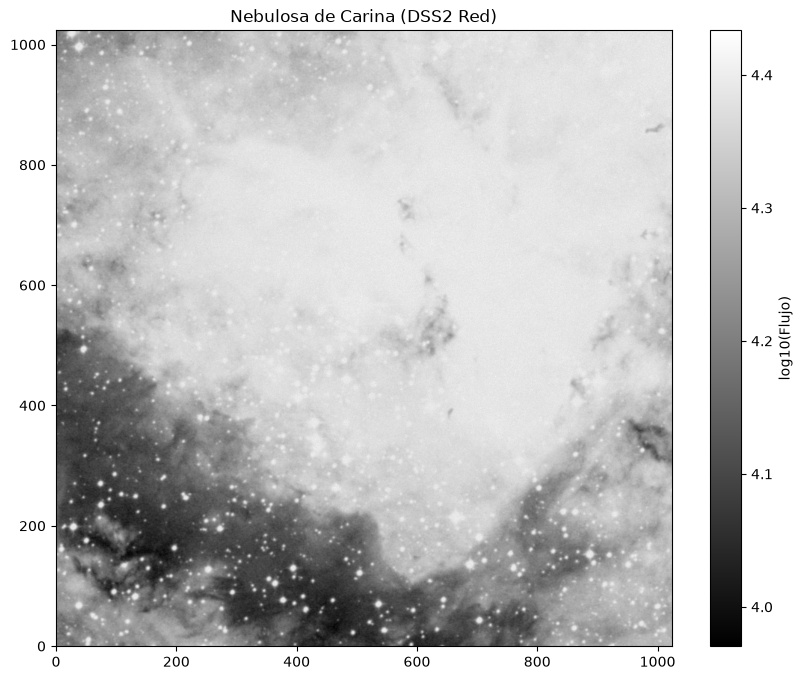

In [31]:
from astroquery.skyview import SkyView
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Pedir una imagen DSS2 roja centrada en NGC 3372, de 1024 píxeles
hdu_list = SkyView.get_images(position="NGC 3372", survey=["DSS2 Red"], pixels=1024)

# La función devuelve una lista; tomamos el primer HDU
hdu = hdu_list[0][0]

# Guardar en un archivo FITS local
hdu.writeto('carina_ngc3372.fits', overwrite=True)

# Abrir y mostrar los datos
with fits.open('carina_ngc3372.fits') as hdul:
    data = hdul[0].data
    header = hdul[0].header
    print(header)  # ver la cabecera

# Visualizar con escala logarítmica para resaltar detalles
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(data + 1), cmap='gray', origin='lower')
plt.colorbar(label='log10(Flujo)')
plt.title('Nebulosa de Carina (DSS2 Red)')
plt.show()

In [32]:
hdul.info()

Filename: carina_ngc3372.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     128   (1024, 1024)   float32   


In [33]:
hdul.close()

In [34]:
with fits.open('carina_ngc3372.fits') as hdul:
    hdul.info()

Filename: carina_ngc3372.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     128   (1024, 1024)   float32   


### 1.1. Headers and Data (Headers and Data)

Each HDU object contains the `.header` and `.data` attributes. Using the `header` attribute it is possible to access the header of the HDU object, which contains all the information of this data unit,### 1.1. Headers and Data (Headers and Data)

In [35]:
hdul[0].header

SIMPLE  =                    T / Written by SkyView Mon Jul 27 14:24:50 EDT 2026
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                 1024 / Width of image                                 
NAXIS2  =                 1024 / Height of image                                
CRVAL1  =              161.259 / Reference longitude                            
CRVAL2  =             -59.6999 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                512.5 / X reference pixel                              
CRPIX2  =                512

In [36]:
hdul[0].header['COMMENT']


SkyView Survey metadata

info:        query coordinates guaranteed to return data for this surv
         ey
ra:          0
dec:         0
radius:      1
Provenance:  Data taken by ROE, AAO, and CalTech, Compression
                     and distribution by Space Telescope Science Inst
         itute.
Copyright:   There are multiple copyright holders depending         up
         on the source plate or plates.          See full copyright
                notices The coverage link below describes the
          coverage for each element of the surveys when the original
         plate used is         not included in the SkyView files..
Regime:      Optical
NSurvey:     1
Frequency:   445 THz
Bandpass:    422-564 THz
Coverage:    All-sky, but some data not yet be processed.
PixelScale:  1"
PixelUnits:  Pixel values are given as scaled densities
Resolution:  Depends on plate. Typically 3".
Coordinates: Equatorial
Projection:  Schmidt
Equinox:     2000
Epoch:       1984-1999
Reference:   Some 

On the other hand, the `data` attribute gives access to the information stored in the HDU. For example, in the specific case we are working on, we will assign this information to the image_data variable.

**Note: It is important to assign this information before closing the file!**

In [37]:
hdul = fits.open('carina_ngc3372.fits')
image_data = hdul[0].data
hdul.close()


The information has been saved as a NumPy array.

In [38]:
type(image_data)

numpy.ndarray

In [39]:
image_data.shape


(1024, 1024)

In this way we can easily access the data.

In [40]:
image_data[10:15 , 20:30]

array([[14886., 14886., 14886., 15161., 14886., 14611., 14542., 14267.,
        14405., 14680.],
       [15161., 15161., 14886., 15161., 14886., 14611., 14817., 14542.,
        14405., 14680.],
       [15299., 15299., 14886., 14886., 14474., 14749., 15230., 14955.,
        14680., 14955.],
       [15574., 15574., 15436., 14886., 14749., 15024., 15230., 14955.,
        15230., 15505.],
       [15866., 15866., 15591., 15041., 14628., 15178., 15247., 15247.,
        15522., 15797.]], dtype='>f4')

We can also obtain important statistical information.

In [41]:
np.min(image_data)


np.float32(9337.0)

In [42]:
np.max(image_data)


np.float32(27132.0)

In [43]:
np.mean(image_data)


np.float32(20701.96)

## 2. Image Display

For the file we are considering, the information stored corresponds to a photometric image of the nebula. In this way, we can use a function like [matplotlib.pyplot.imshow()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.imshow.html) to display the image

http://learn.astropy.org/rst-tutorials/FITS-images.html?highlight=filtertutorials

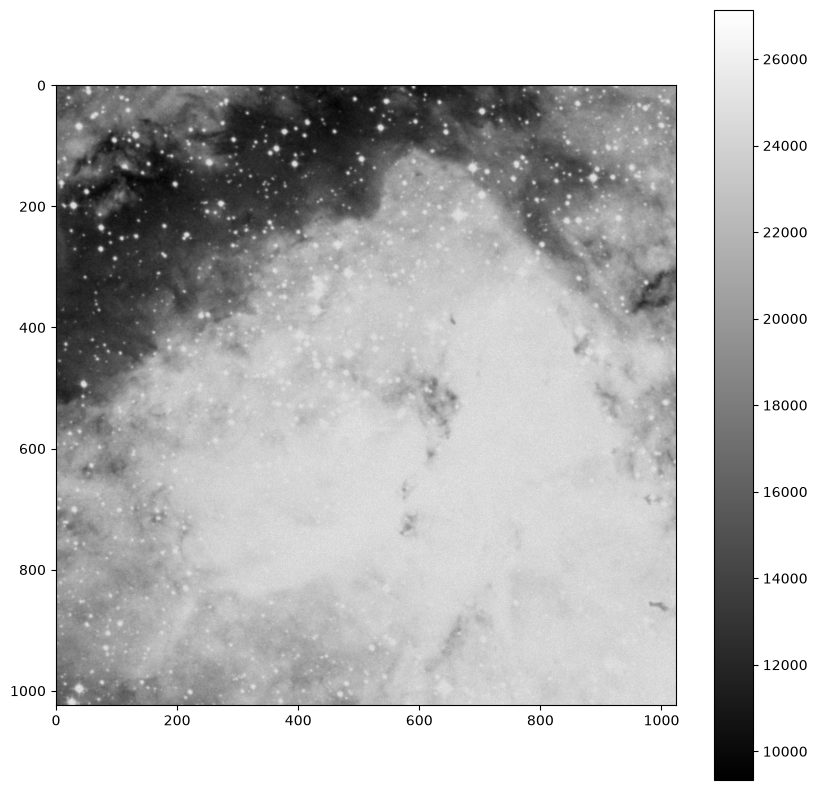

In [44]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='gray')
plt.colorbar()
plt.show()


The 'gray' color map can be changed. [There are multiple options](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

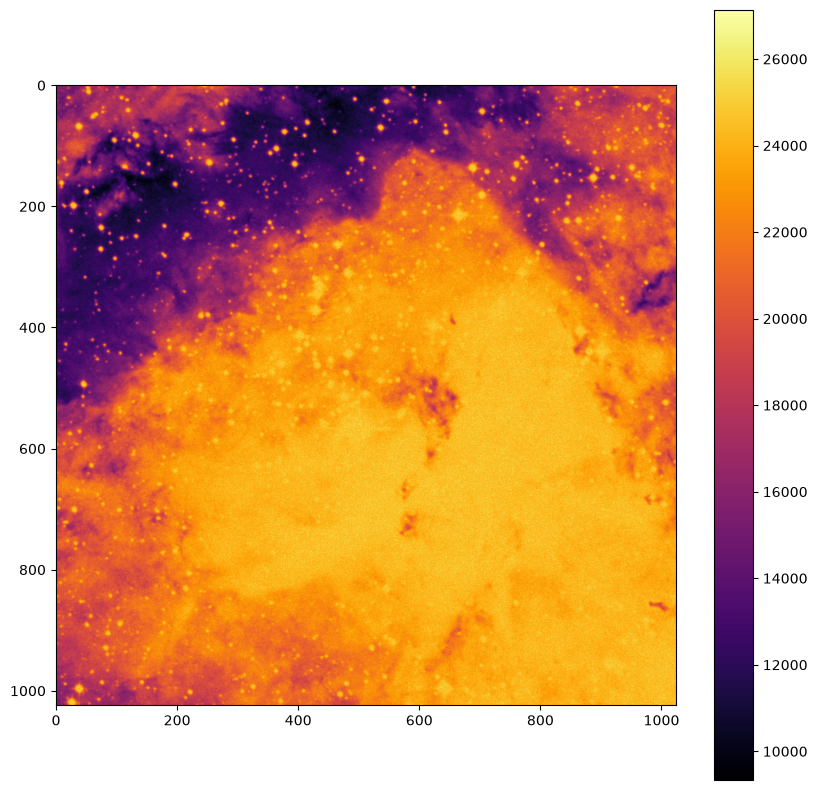

In [45]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='inferno')
plt.colorbar()
plt.show()


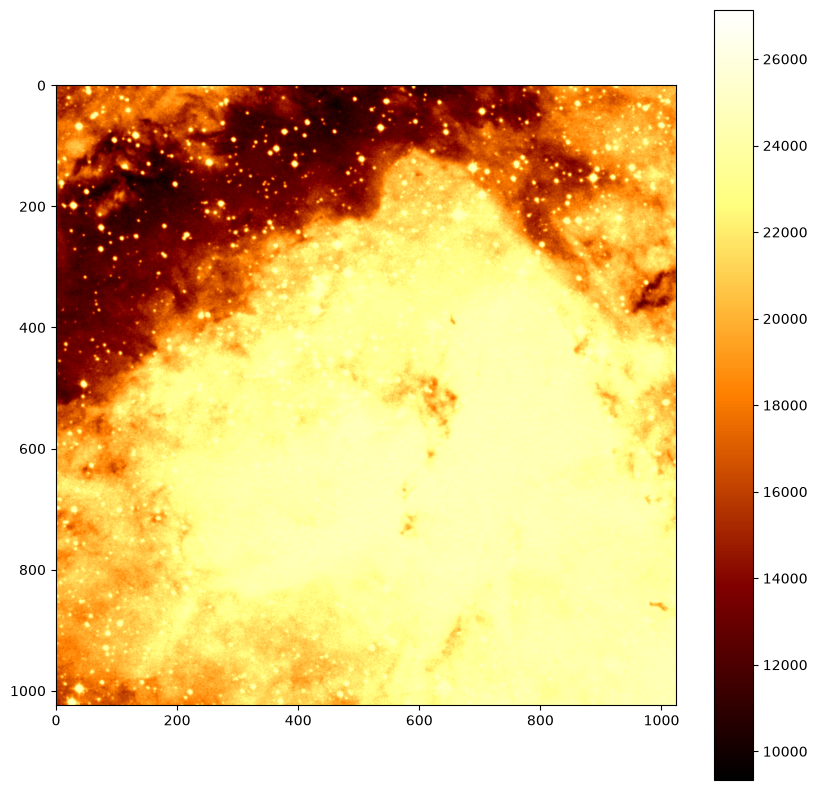

In [46]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot')
plt.colorbar()
plt.show()


Additionally, a logarithmic color scale can be used to highlight details using the [matplotlib.colors.LogNorm](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.colors.LogNorm.html) function.

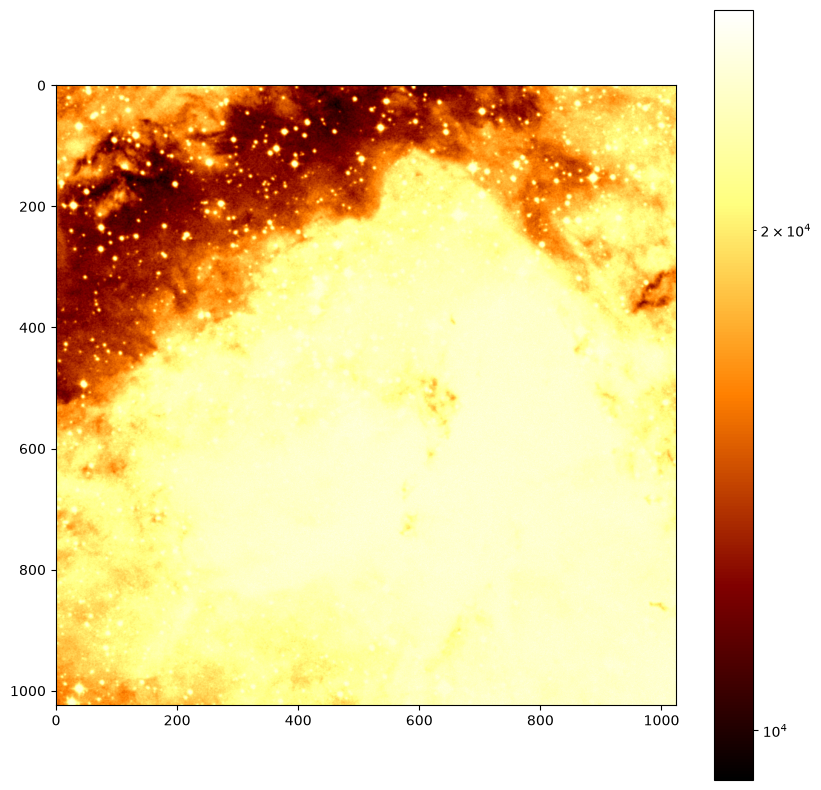

In [47]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot', norm=LogNorm())
plt.colorbar()
plt.show()

### 2.1. Histogram
The data in the 2D array can be flattened.

In [53]:
flat_data = image_data.flatten()


and with this a histogram can be built to visualize what values (colors) appear within the image [matplotlib.pyplot.hist()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.hist.html)

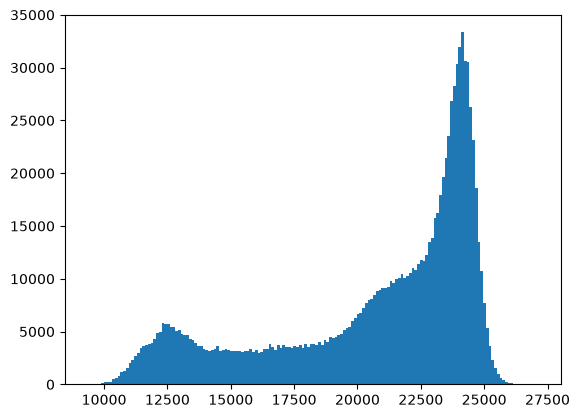

In [54]:
plt.figure()
plt.hist(flat_data, bins='auto') 
plt.show()

With this information it is possible to redisplay the image by removing some of the points in order to enhance details and improve the image

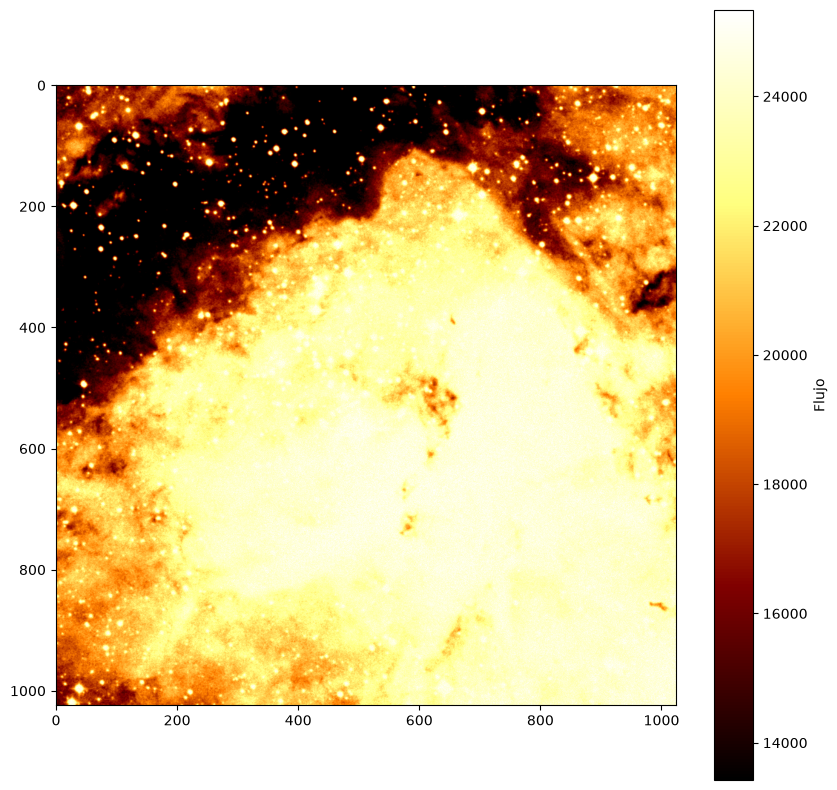

In [ ]:
import numpy as np
vmin = np.nanpercentile(image_data, 10)   # oscuro
vmax = np.nanpercentile(image_data, 99.5) # brillante, evita los pocos píxeles extremos

plt.figure(figsize=(10, 10))
plt.imshow(image_data, cmap='afmhot', vmin=vmin, vmax=vmax)
plt.colorbar(label='Flujo')
plt.show()

In [56]:
!pip install imageio

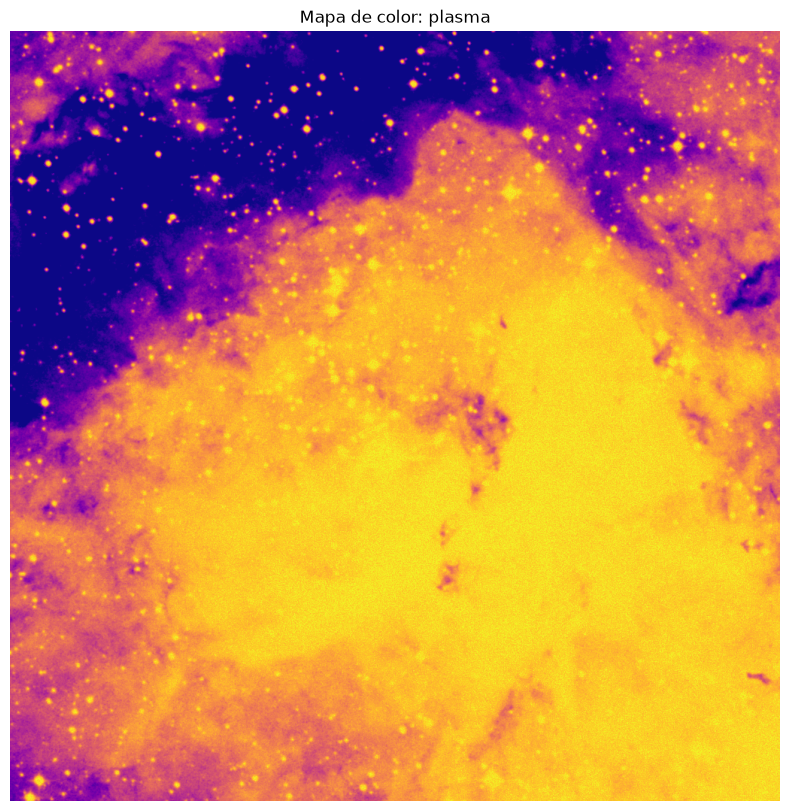

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import imageio.v2 as imageio

# 1. Normalizar datos 
vmin = np.nanpercentile(image_data, 10)
vmax = np.nanpercentile(image_data, 99.5)
norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
datos_norm = norm(image_data)  # valores entre 0 y 1
nombre_cmap = 'plasma'     


cmap = plt.get_cmap(nombre_cmap)

# 3. Aplicar mapa de color y convertir a RGB
imagen_rgba = cmap(datos_norm)
imagen_rgb = imagen_rgba[:, :, :3]

# Convertir a 8 bits para guardar
imagen_rgb_8bit = (imagen_rgb * 255).astype(np.uint8)

# Guardar
imageio.imwrite(f'nebulosa_{nombre_cmap}.jpg', imagen_rgb_8bit)

# Mostrar en pantalla
plt.figure(figsize=(10, 10))
plt.imshow(imagen_rgb)
plt.title(f'Mapa de color: {nombre_cmap}')
plt.axis('off')
plt.show()